## **Rational Nonlinearity Learned by SREINet**


## **I. Setup and Preprocessing**

In [1]:
# Import os library to access environment variables and operating system functionalities
import os

# Set environment variable to avoid duplicate library errors, specifically for OpenMP
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# Set TensorFlow log level to '2' to suppress most messages except warnings and errors
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import sys
sys.path.append("../utilities")

# Import necessary libraries for deep learning and numerical computation
import tensorflow as tf
import numpy as np
from SREINet import * 
import DataGenerator as DG


# Print a formatted message to the terminal to display current time, date, and TensorFlow version
print("**********************************************")
print("*                                            *")
print("*    Tensorflow Version: " + tf.__version__ + "              *")
print("*                                            *")
print("**********************************************")

from packaging import version
if version.parse(tf.__version__) < version.parse('2.10.0') and version.parse(tf.__version__) > version.parse('2.15.0'):
    print("Error: Tensorflow version is lower than 2.10.0 or higher than 2.15.0 Please use Tensorflow 2.10.0 - 2.15.0")
    sys.exit()

MY_DATA_TYPE = 'float32'
# Set the desired data type
tf.keras.backend.set_floatx(MY_DATA_TYPE)  


**********************************************
*                                            *
*    Tensorflow Version: 2.15.0              *
*                                            *
**********************************************


#### Create dataset

Guessed multiplicative_order: 3


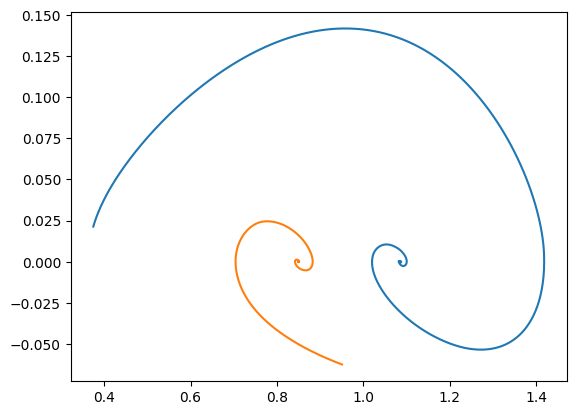

Training input shape: (2000, 2)
Training output shape: (2000, 2)


In [2]:
# Specify the model type
MY_MODEL = 'rosenzweig_macArthur' 
MY_DATA_TYPE = 'float32'

# Set the desired data type
tf.keras.backend.set_floatx(MY_DATA_TYPE)  

# Generate data based on the specified model
dim = 2
num_traj = 1
data_initial_conditions = DG.DataGenerator.generate_initial_conditions(dim, num_traj, seed=42) #np.random.normal(1, 2, LORENZ96_DIM

data_T =  100.0       # Length of the data (T)
data_dt = 0.05       # Resolution of the data (dt)
myDG = DG.DataGenerator(data_initial_conditions, T=data_T, dt=data_dt, derivative_mode="exact")



t_arr, x_train, dx_train, guessed_multiplicative_order = myDG.generate_dataset_by_model_name(MY_MODEL, method='RK45')

print("Guessed multiplicative_order:", guessed_multiplicative_order)

#plot x_train and dx_train
import matplotlib.pyplot as plt
plt.plot(x_train, dx_train)
plt.show()

#Shuffle data
training_input, training_output = x_train, dx_train
# Optionally, save a copy of the training input for simulation
training_input_for_sim = training_input.copy() # Saving a copy of training input for simulation (Before shuffling)

training_input, training_output = myDG.shuffleData(training_input, training_output)

print("Training input shape:", training_input.shape)
print("Training output shape:", training_output.shape)

### **1.3 Hyperparameters**


In [3]:
# Set mini-batch size
MINI_BATCH_SIZE = 32
learning_rate = 0.001

### **1.4 Model Architecture Definitions**


**SREINet Parameters**

In [4]:
# Assign dim to be the 2nd dimension of the training data (number of input variables)
dim = training_input.shape[1] 

# The grid size of each dimension
layer_depth = guessed_multiplicative_order
layer_neuron_nums_per_act_fn = [dim] * layer_depth
print(layer_neuron_nums_per_act_fn) # these numbers exclude the constant term

[2, 2, 2]


## **II. Model and Training Preparation**


### **2.1 Create the SREINet Model**


In [29]:
class LiftingLayer(tf.keras.layers.Layer):
    """
    Simple transformation layer that generates input to SREINet. This layer allows for incorporating 
    custom transformation functions such as 1/(ax+b) and xi*xj.
    """
    
    def __init__(self, weight_std=0.001, delta=1e-4, seed=42, **kwargs):
        """
        Args:
            input_dim: Input dimension (number of input features)
            weight_std: Standard deviation for weight initialization
            delta: Small constant to prevent division by zero
            seed: Random seed
        """
        super(LiftingLayer, self).__init__(**kwargs)
        self.delta = delta
        self.seed = seed
        
    
    def build(self, input_shape):

        # Create learnable parameters for 1/(x+b)
        # Shape should match the last dimension of input for proper broadcasting
        self.b = self.add_weight(
            name='b', shape=(input_shape[-1],),
            initializer=tf.initializers.random_normal(),
            trainable=True
        )

    def call(self, inputs):
        """
        Apply transformations: [original_coords, 1/(ax+b), custom_transforms]
        """
        
        # Add rational transformation 1/(x + b)
        ax_plus_b = self.b*inputs + 1
        rational_output = ax_plus_b / (ax_plus_b**2 + self.delta) #
        

        
        return tf.concat([inputs, rational_output], axis=-1)
    

    

In [30]:

def create_extended_sreinet_model(dim, layer_neuron_nums_per_act_fn, activation_functions=[lambda x:x], 
                        weight_std=0.001, delta=1e-5, seed=42, data_type='float32'):
    """
    Create and initialize a SREINet model.
    
    Args:
        dim (int): Input dimension (number of input variables)
        layer_neuron_nums_per_act_fn (list): Number of neurons per activation function in each hidden layer
        activation_functions (list, optional): List of activation functions. Defaults to [lambda x:x]
        weight_std (float, optional): Standard deviation for weight initialization. Defaults to 0.001
        delta: small constant to avoid division by zero
        seed (int, optional): Random seed for reproducible initialization. Defaults to 42
        data_type (str, optional): Data type for the model. Defaults to 'float32'
    
    Returns:
        tf.keras.Model: Configured SREINet model
    """
    
    # Create input layer
    inputs = tf.keras.layers.Input(shape=(dim,), dtype=data_type)

    # Apply flexible transformation layer (includes original coordinates + transformations)
    lifting_layer = LiftingLayer(
        delta=delta,
        seed=seed,
        name='lifting_layer'
    ) #DO NOT CHANGE THIS NAME
    
    # Get transformed features (includes original coordinates automatically)
    transformed_inputs = lifting_layer(inputs)

    # Calculate output dimension for SREINet layers
    #need to revise, confusing

    layer_neuron_nums_per_act_fn = [transformed_inputs.shape[1] for x in layer_neuron_nums_per_act_fn]
    
    # Create SREINet model
    sreinet = SREINet(layer_neuron_nums_per_act_fn,
                      activations=activation_functions,
                      weight_initializer=tf.initializers.random_normal(stddev=0.0001, seed=seed),
                      data_type=data_type,
                      name='SREINet') #DO NOT CHANGE THIS NAME
    
    # Apply the SREINet to transformed inputs
    output = sreinet(transformed_inputs)
    
    # Create the final model
    model = tf.keras.Model(inputs=inputs, outputs=output)
    
    return model


model = create_extended_sreinet_model(dim, layer_neuron_nums_per_act_fn)


def reinitialize_model_weights(model):
    """
    Reinitialize weights of the SREINet model.
    
    Args:
        model (tf.keras.Model): The SREINet model to reinitialize
    """
    #need to update here

    if hasattr(model.layers[1], 'reinitialize_weights'):
        tf.random.set_seed(np.random.randint(10000))
        model.layers[1].reinitialize_weights()
    else:
        print("SREINet does not have a reinitialize_weights() function.")

In [31]:
model.summary()


Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 2)]               0         
                                                                 
 lifting_layer (LiftingLaye  (None, 4)                 2         
 r)                                                              
                                                                 
 SREINet (SREINet)           (None, 1)                 55        
                                                                 
Total params: 57 (228.00 Byte)
Trainable params: 52 (208.00 Byte)
Non-trainable params: 5 (20.00 Byte)
_________________________________________________________________


### **2.2 Loss Function**

In [32]:
LOSS_FUNCTION = 'mse' #This can be 'MSE', 'LASSO', or 'RIDGE' or 'ElasticNet'(case insensitive)

from loss import *

# Example of selecting a loss function
loss_fn = myLoss(model, LOSS_FUNCTION) 

### **2.3 Optimizer**

In [33]:
my_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)  # Create an Adam optimizer with the defined learning rate

### **2.4 Training with Pruning**

In [34]:
import time
np.set_printoptions(threshold=np.inf)

# Define a training step function
@tf.function
def train_step(model, optimizer, loss_fn, inputs, targets, binary_mask):        
    with tf.GradientTape() as tape:
        # Generate predictions and calculate loss
        predictions = model(inputs, training=False)
        loss = loss_fn(targets, predictions)   
        
    # Calculate gradients and update model weights
    gradients = tape.gradient(loss, model.trainable_variables)        

    # Assuming binary_masks_ones is a list of binary masks created for each trainable variable
    masked_gradients = [tf.multiply(grad, mask) for grad, mask in zip(gradients, binary_mask)]

    optimizer.apply_gradients(zip(masked_gradients, model.trainable_variables))

    return loss

# Define a validation step function
@tf.function
def val_step(model, loss_fn, inputs, targets):
    # Generate predictions and calculate loss for validation data
    predictions = model(inputs, training=False)
    # predictions = model(inputs, training=False) 
    v_loss = loss_fn(targets, predictions)
    # Record the validation loss
    return v_loss   

def SREINet_fit_w_pruning(
    model,              # TensorFlow model to be trained
    training_input,     # Input features for training
    training_output,    # Target outputs for training
    batch_size,         # Number of samples per batch of computation
    validation_split,   # Fraction of data to be used as validation set
    epochs,             # Number of complete passes through the training dataset
    optimizer,          # Optimization algorithm for updating weights
    loss_fn,            # Loss function to measure model's performance
    pruning_schedule,   # Pruning schedule for gradually increasing the sparsity level
    data_type='float32',    # Data type of the tensors (default: 'float32')
    callbacks=None,         # List of callbacks for custom actions at various stages of training
    early_stopping_loss_threshold=0,       # Threshold for early stopping based on training and validation loss
    early_stopping_pruning_threshold=0,    # Threshold for early stopping based on pruning schedule
    verbose=0               # Verbosity mode (0 = silent, 1 = progress bar, etc.)
):
    # Cast the training input and output to the specified data type
    training_input = tf.cast(training_input, data_type)
    training_output = tf.cast(training_output, data_type)

    # Shuffle and batch the dataset, then split it into training and validation sets
    full_dataset = tf.data.Dataset.from_tensor_slices((training_input, training_output)).shuffle(buffer_size=1024)
    total_samples = training_input.shape[0]
    train_samples = int(total_samples * (1 - validation_split))
    
    # Apply the data type casting for each batch in the datasets
    train_dataset = full_dataset.take(train_samples).batch(batch_size).map(lambda x, y: (tf.cast(x, data_type), tf.cast(y, data_type)))
    val_dataset = full_dataset.skip(train_samples).batch(batch_size).map(lambda x, y: (tf.cast(x, data_type), tf.cast(y, data_type)))

    # Initialize metrics for tracking training and validation loss
    train_loss = tf.keras.metrics.Mean(name='train_loss', dtype=data_type)
    val_loss = tf.keras.metrics.Mean(name='val_loss', dtype=data_type)
    
    # Parameters initialization
    binary_mask = [tf.ones_like(var) for var in model.trainable_variables]

    def generate_binary_mask_and_prune_weight(model, pruning_weight_threshold):
        binary_masks = [tf.ones_like(var) for var in model.get_layer('lifting_layer').trainable_variables]  # Initialize list to hold binary masks
        
        # Iterate over each variable to apply the pruning threshold and generate masks
        for var in model.get_layer('SREINet').trainable_variables:
            # Generate a binary mask where weights above the PRUNING_WEIGHT_THRESHOLD are marked with 1, others with 0
            mask = tf.cast(tf.abs(var) >= pruning_weight_threshold, var.dtype)

            # Update the mask at position (0, 0) to be 1 using tf.tensor_scatter_nd_update (To Avoid the constant term being pruned)
            indices = tf.constant([[0, 0]])  # Specify the indices to update
            updates = tf.constant([1], dtype=mask.dtype)  # Specify the value to update
            mask = tf.tensor_scatter_nd_update(mask, indices, updates)

            binary_masks.append(mask)  # Add the generated mask to the list            

            # Apply mask to modify weights by setting weights below PRUNING_WEIGHT_THRESHOLD to zero
            modified_weight = var * mask
            var.assign(modified_weight)            
        return binary_masks

    # Prepare a dictionary to track the training history
    history = {'loss': [], 'val_loss': []}

    # Before the training loop starts
    if callbacks:
        for callback in callbacks:
            # Assign the model to the callback
            callback.set_model(model)

            # Manually setting params before calling any methods that might depend on them
            callback.params = {
                'epochs': epochs,  # Number of epochs
                # You can add more parameters here as needed
            }

            # Now call on_train_begin with all properties set
            callback.on_train_begin(logs={'loss_threshold': early_stopping_loss_threshold})

    training_start_time = time.time()
    # Execute the training loop
    for epoch in range(epochs):
        # Notify callbacks that the epoch has started
        if callbacks:
            epoch_logs = {}
            for callback in callbacks:
                callback.on_epoch_begin(epoch, logs=epoch_logs)

        if verbose: 
            eopoch_start_time = time.time()

        # Reset state of metrics at the start of each epoch
        train_loss.reset_states()
        val_loss.reset_states()

        # Retrieve the current pruning schedule threshold
        current_pruning_threshold = pruning_schedule[epoch]
        binary_mask = generate_binary_mask_and_prune_weight(model, current_pruning_threshold)
        
        layer_losses_sum = None
        layer_indices = [i for i, layer in enumerate(model.layers) if layer.trainable]
        # Process each batch in the training dataset
        for train_inputs, train_targets in train_dataset:           
            loss = train_step(model = model, 
                            optimizer = optimizer, 
                            loss_fn = loss_fn,
                            inputs = train_inputs, 
                            targets = train_targets, 
                            binary_mask = binary_mask)    
            # Record the loss
            train_loss(loss)

        # Process each batch in the validation dataset
        for val_inputs, val_targets in val_dataset:
            v_loss = val_step(model = model, 
                                loss_fn = loss_fn,
                                inputs = val_inputs, 
                                targets = val_targets)
            val_loss(v_loss)

        # Append the average losses for this epoch to the history
        history['loss'].append(train_loss.result().numpy())
        history['val_loss'].append(val_loss.result().numpy())
        #calculate the average of val_loss
        
        # Current Losses
        current_train_loss = train_loss.result().numpy()
        current_val_loss = val_loss.result().numpy()

        # Notify callbacks that the epoch has ended
        epoch_logs = {'loss': current_train_loss, 'val_loss': current_val_loss}
        if callbacks:
            for callback in callbacks:
                callback.on_epoch_end(epoch, logs=epoch_logs)
    
        if verbose:
            epoch_time = time.time() - eopoch_start_time
            total_layers = len(model.layers)
            trainable_layer_count = sum(1 for layer in model.layers if layer.trainable)
            print(f"Epoch {epoch + 1:3.0f}:"
                f"  Train Loss: {current_train_loss:9.4e}"
                f",  Validation Loss: {current_val_loss:9.4e}"
                # f",  Trainable Layers ({trainable_layer_count}/{total_layers})"
                f",  Epoch Time: {epoch_time:.2f}s"  
                f",  Current Pruning Threshold: {current_pruning_threshold:.5g}")    
            
        if model.stop_training: # Stop training if all the layers are untrianable
            break   

        # Check for early stopping
        if current_train_loss < early_stopping_loss_threshold and current_pruning_threshold > early_stopping_pruning_threshold:
            print(f"Early stopping at epoch {epoch+1} as train loss {current_val_loss:.12f} is below the threshold {early_stopping_loss_threshold:.12f}")
            break


    # After the training loop ends
    training_time = time.time() - training_start_time
    print(f'Traininng Stopped. Time elapsed: {training_time:.2f}s')
    if callbacks:
        for callback in callbacks:
            callback.on_train_end(logs={'final_loss': current_train_loss, 'final_val_loss': current_val_loss})
    

    # Return the history containing training and validation losses
    return history

## **III.Training the Model**

#### **Pruning Profile**

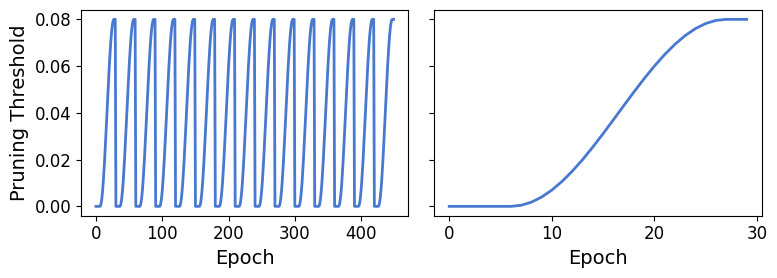

In [36]:
MAX_WEIGHT_PRUNING_THRESHOLD = 0.08 #Threshold for 10D Lorenz 96 model. Uses linear prune schedule
N_PERIODS = 15
PRUNING_EPOCHS_PER_PERIOD = 30
NUM_EPOCHS = PRUNING_EPOCHS_PER_PERIOD * N_PERIODS

import pruning_schedule as ps

# Define the pruning schedule
pruning_schedule = ps.pruning_schedule_ramp(maximum_threshold=MAX_WEIGHT_PRUNING_THRESHOLD, 
                                                    steps_per_period=PRUNING_EPOCHS_PER_PERIOD, 
                                                    num_periods=N_PERIODS, 
                                                    #zero_percentage=0.10,
                                                    show_plot=True)

### Training

In [37]:
#Setup
callbacks = []

EARLY_STOPPING_LOSS_THRESHOLD = 1e-10   # Threshold for early stopping (Layer Based)
EARLY_STOPPING_PRUNING_THRESHOLD = 0.02

training_histories = []
weights_list = []
lifting_layer_weights_list = []

In [38]:
#change 0 to a other number if you want to start training from other dimensions
for i in range(0, training_output.shape[1]):
    print(f"Training dimension {i + 1}...")
    
    reinitialize_model_weights(model)
    output = training_output[:, i:i+1]

    history = SREINet_fit_w_pruning(
        model,                   # Model to train
        training_input,             # Input data for training
        output,                     # Output data for training
        batch_size=MINI_BATCH_SIZE, # Number of samples per gradient update
        validation_split=0.20,      # Fraction of the training data to be used as validation data
        epochs=round(NUM_EPOCHS),   # Number of times the entire training dataset is passed through the model
        optimizer=my_optimizer,     # Optimizer to use for training
        pruning_schedule = pruning_schedule, # Pruning schedule for gradually increasing the sparsity level
        loss_fn=loss_fn,            # Loss function to use for training
        data_type=MY_DATA_TYPE,     # Data type to use for training
        callbacks= callbacks,       # List of callbacks to apply during training
        early_stopping_loss_threshold=EARLY_STOPPING_LOSS_THRESHOLD,# Threshold for early stopping (Layer Based)
        early_stopping_pruning_threshold=EARLY_STOPPING_PRUNING_THRESHOLD, # Threshold for early stopping (Pruning Based)
        verbose=1                   # Hide the epoch steps
    )
    
    training_histories.append(history)

    # Retrieve the weights of the trained model
    weights_list.append([model.get_layer('SREINet').get_weights()])
    lifting_layer_weights_list.append([model.get_layer('lifting_layer').get_weights()])
   

Training dimension 1...
SREINet does not have a reinitialize_weights() function.
Epoch   1:  Train Loss: 1.2397e-03,  Validation Loss: 1.1053e-03,  Epoch Time: 0.26s,  Current Pruning Threshold: 0
Epoch   2:  Train Loss: 1.2585e-03,  Validation Loss: 1.1203e-03,  Epoch Time: 0.05s,  Current Pruning Threshold: 0
Epoch   3:  Train Loss: 1.2357e-03,  Validation Loss: 1.3049e-03,  Epoch Time: 0.04s,  Current Pruning Threshold: 0
Epoch   4:  Train Loss: 1.0605e-03,  Validation Loss: 8.3095e-04,  Epoch Time: 0.04s,  Current Pruning Threshold: 0
Epoch   5:  Train Loss: 1.0426e-03,  Validation Loss: 8.6328e-04,  Epoch Time: 0.04s,  Current Pruning Threshold: 0
Epoch   6:  Train Loss: 9.6134e-04,  Validation Loss: 9.3688e-04,  Epoch Time: 0.04s,  Current Pruning Threshold: 0
Epoch   7:  Train Loss: 8.8200e-04,  Validation Loss: 9.2458e-04,  Epoch Time: 0.04s,  Current Pruning Threshold: 0
Epoch   8:  Train Loss: 7.2054e-04,  Validation Loss: 6.5213e-04,  Epoch Time: 0.04s,  Current Pruning Thre

## **IV. Coefficient Reconstructor (SREINet)**

In [40]:
lifting_layer_weights_list[0]

[[array([-0.24124043,  0.23935874], dtype=float32)]]

In [41]:
weights_list[0]

[[array([[-0.09575976, -0.        ,  0.        ,  0.12975681, -0.08649018],
         [-0.        ,  0.21685047, -0.        ,  0.        , -0.        ],
         [ 0.        ,  0.24001318, -0.320743  ,  0.        ,  0.        ],
         [-0.14262462, -0.        , -0.        ,  0.15202093, -0.1384911 ],
         [-0.09568417, -0.        , -0.15098956,  0.13527782, -0.08746734]],
        dtype=float32),
  array([[-0.08606491, -0.        ,  0.        , -0.13308313, -0.08628106],
         [ 0.        , -0.21634762, -0.23712794,  0.        ,  0.        ],
         [ 0.1885123 , -0.        ,  0.23246223,  0.2281387 ,  0.19782521],
         [ 0.1294261 ,  0.        ,  0.        ,  0.15175803,  0.13517223],
         [-0.08703874, -0.        ,  0.        , -0.13957936, -0.08841634]],
        dtype=float32),
  array([[1.],
         [1.],
         [1.],
         [1.],
         [1.]], dtype=float32)]]

#### `generate_set_labels`

In [24]:
def generate_set_labels(N):
    return ['Constant'] + [f'x{i}' for i in range(1, N+1)]

#### `coefficient_reconstruction`

In [25]:
def coefficient_reconstruction(dim_index,
                                weights, 
                                minimum_coefficient_threshold = 1e-5,
                                coefficient_output_digits = 10, 
                                enable_coefficient_sorting = False):
    
    max_neurons = max(max(len(layer) for layer in SREINet) for SREINet in weights)
    
    labels = generate_set_labels(max_neurons - 1) # number of states = number of neurons - 1

    def explore_path(SREINet_index, layer, neuron, weight_product, label_counts, non_zero_paths):
        """
        Recursively explores non-zero paths in a neural network.
        """
        if layer == len(weights[SREINet_index]) - 1:
            non_zero_paths.append((label_counts, weight_product))
            return

        for next_neuron, weight in enumerate(weights[SREINet_index][layer][neuron]):
            if abs(weight) <= 1e-15:
                # Skip recursion if the weight is zero (if one weight is zero, the whole path will be eliminated)
                continue  
            new_weight_product = weight_product * weight
            next_label_counts = label_counts.copy()
            next_label_counts[labels[next_neuron]] = next_label_counts.get(labels[next_neuron], 0) + 1
            explore_path(SREINet_index, layer + 1, next_neuron, new_weight_product, next_label_counts, non_zero_paths)
    
    #beginning of the algorithm
    all_SREINet_products = []
    for SREINet_index, _ in enumerate(weights):
        non_zero_paths = []
        #collect all non-zero paths
        for neuron_index in range(len(weights[SREINet_index][0])):
            label_counts = {labels[neuron_index]: 1}
            explore_path(SREINet_index, 0, neuron_index, 1, label_counts, non_zero_paths)
        
        #sum up the products with identical composite nonlinear/linear terms
        SREINet_products = {}
        for label_counts, weight_product in non_zero_paths:
            label_counts_key = frozenset(label_counts.items())
            if label_counts_key in SREINet_products:
                SREINet_products[label_counts_key] += weight_product
            else:
                SREINet_products[label_counts_key] = weight_product
        
        #remove the negligible composite terms
        SREINet_products = {k: v for k, v in SREINet_products.items() if abs(v) >= minimum_coefficient_threshold}
        
        if enable_coefficient_sorting:
            #sort the composite terms by their absolute values
            sorted_SREINet_products = dict(sorted(SREINet_products.items(), key=lambda item: abs(item[1]), reverse=True))
        else:
            sorted_SREINet_products = SREINet_products

        all_SREINet_products.append(sorted_SREINet_products)

    #output formatting
    labeled_all_SREINet_products = []
    for SREINet_index, sorted_SREINet_products in enumerate(all_SREINet_products):
        SREINet_product_strings = []
        for key, value in sorted_SREINet_products.items():
            labels_list = []
            only_constant = len(key) == 1 and any(label == 'Constant' for label, _ in key)
            
            for label, count in sorted(key):
                if label == 'Constant' and len(key) > 1:
                    continue
                if label != 'Constant' and count > 1:
                    labels_list.append(f"{label}^{count}")
                elif label == 'Constant' or count == 1:
                    labels_list.append(label if label != 'Constant' else '')
            
            label_str = '*'.join(filter(None, labels_list))
                        
            # Apply coefficient threshold if enabled
            formatted_value = f"{abs(value):.{coefficient_output_digits}g}"

            term_str = label_str if formatted_value == '1' else f"{formatted_value}*{label_str}" if not only_constant else formatted_value if formatted_value != '1' else ''
            sign = '+' if value >= 0 else '-'
            if SREINet_product_strings or value < 0:
                term_str = f" {sign} {term_str}"
            else:
                term_str = term_str
            SREINet_product_strings.append(term_str)

        formatted_output = ''.join(SREINet_product_strings)
        layer_prefix = f"(x{SREINet_index+dim_index+1})'= "
        full_output = layer_prefix + formatted_output
        labeled_all_SREINet_products.append(full_output)

    return labeled_all_SREINet_products

## **V. Results**
### **Identified Model**

In [26]:
for i in range(len(weights_list)):
    path_products = coefficient_reconstruction(i,weights_list[i], 
                                            minimum_coefficient_threshold = 1e-2,
                                            coefficient_output_digits = 10, 
                                            enable_coefficient_sorting = False)
    
    for index, dimension in enumerate(path_products):
        print(f"{dimension}")

(x1)'= 0.02723511377*x4 - 0.01621054624*x1*x2 - 0.02060827895*x2^2 + 0.1073351589*x1*x4 + 0.08972605997*x4^2 - 0.0537669589*x1^3 - 0.1365117769*x1^2*x2 + 0.1095871126*x1^2*x4 + 0.1832170695*x1*x4^2 - 0.1047106611*x1*x2^2 - 0.02296251454*x2^3 - 0.01886274576*x1*x2*x3 - 0.02397998935*x2^2*x3 - 0.01401931902*x1*x2*x4 - 0.01782259726*x2^2*x4 + 0.07657944172*x4^3
(x2)'=  - 0.01046114856*x4 + 0.04713750747*x1*x2^2 + 0.02308710676*x1^2*x4 - 0.1269789428*x2^2*x3 - 0.01542578257*x4^2


In [104]:
denominator_SREIENet_weights_list[1]

[[array([[-0.05333758],
         [-0.        ],
         [-0.        ]], dtype=float32)]]

In [84]:
for i in range(len(denominator_SREIENet_weights_list)):
    path_products = coefficient_reconstruction(i,denominator_SREIENet_weights_list[i], 
                                            minimum_coefficient_threshold = 0,
                                            coefficient_output_digits = 10, 
                                            enable_coefficient_sorting = False)
    
    for index, dimension in enumerate(path_products):
        print(f"{dimension}")

(x1)'=  + x1 + x2
(x2)'=  + x1 + x2


### **Validation**

313/313 [==============================] - 0s 179us/step


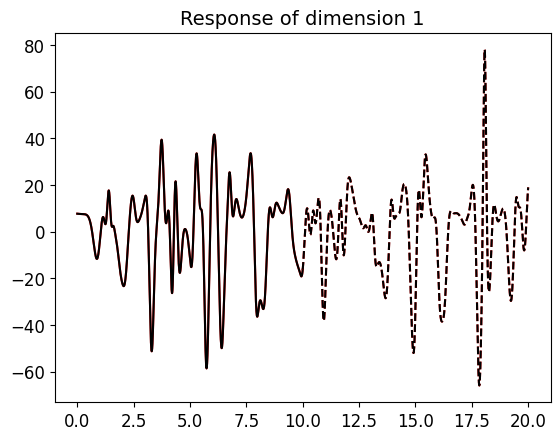

In [ ]:
import matplotlib.pyplot as plt

# validation: need to draw the output of each dimension independently
dim_to_plot = 1
index = dim_to_plot - 1

#Form NN predictions
NN_output = np.zeros((dx_train.shape[0], dx_train.shape[1]))
for i, weight in enumerate(weights_list):
    model.get_layer('SREINet').set_weights(weight[0])
    output = model.predict(training_input_for_sim)
    NN_output[:,i:i+1] = output


#validate the first trajoctory if there are many
plt.plot(t_arr, NN_output[:,index][:t_arr.shape[0]], 'r', label='NN Prediction')
plt.plot(t_arr, dx_train[:,index][:t_arr.shape[0]], 'k', label='Expected Output')


#pick the last point of the simulation output and use it as the initial condition for the next simulation
x0 = x_train[:t_arr.shape[0]][-1]
t0= t_arr[-1]
myDG = DG.DataGenerator(x0,T=data_T+t0, dt=data_dt, t0=t0)
new_t_arr, new_x, new_dx, guessed_multiplicative_order = myDG.generate_dataset_by_model_name(MY_MODEL)

new_input = new_x

new_NN_output= np.zeros((new_dx.shape[0], new_dx.shape[1]))
for i, weight in enumerate(weights_list):
    model.get_layer('SREINet').set_weights(weight[0])
    output = model.predict(new_input)
    new_NN_output[:,i:i+1] = output


#new_NN_output = model.predict(new_input)
plt.plot(new_t_arr, new_NN_output[:,index], "r--", label='NN Prediction')
plt.plot(new_t_arr, new_dx[:,index], "k--", label='Expected Output')
plt.title("Response of dimension " + str(dim_to_plot))
plt.show()
